In [31]:
import numpy as np
import pandas as pd
import xarray as xr
import pickle
import matplotlib.pyplot as plt
import matplotlib as mpl
import gcsfs
import cmocean
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import seaborn as sns
fs = gcsfs.GCSFileSystem()
%run _Val_Mapping.ipynb 

In [2]:
regridded_members_path = "gs://leap-persistent/abbysh/pco2_all_members_1982-2016/post00_regridded_members"

mems_dict = dict()
a = fs.ls(regridded_members_path)
for ens_path in a:
    ens = ens_path.split('/')[-1]
    mems = fs.ls(ens_path)
    for mem in mems:
        memo = mem.split('/')[-1]
        
        if ens not in mems_dict:
            mems_dict[ens] = [memo]

        elif ens in mems_dict:
            mems_dict[ens].append(memo)

if 'CanESM5' in mems_dict and 'member_r6i1p2f1' in mems_dict['CanESM5']:
    mems_dict['CanESM5'].remove('member_r6i1p2f1')

# Residual ORG

In [ ]:
datasets_ens_org = []
for ens, mem_list in mems_dict.items():
    datasets_member = []
    for n_member, member in enumerate(mem_list):
        truth_path = f'gs://leap-persistent/abbysh/pco2_all_members_1982-2023/00_regridded_members/{ens}/{member}/{ens}.{member.split("_")[-1]}.Omon.zarr'
        recon_path = f"gs://leap-persistent/abbysh/pco2_all_members_1982-2023/post02_1982-2023_outputs/reconstructions/{ens}/{member}/recon_pCO2_{ens}_{member}_mon_1x1_198202_202312.zarr"
        kwargs = dict(chunks={'time':-1})
        
        truth = xr.open_dataset(truth_path, engine='zarr',**kwargs).spco2 
        unseen = xr.open_dataset(recon_path, engine='zarr',**kwargs).pCO2_recon_unseen 


        truth = truth.assign_coords(status='truth')
        unseen = unseen.assign_coords(status='unseen')
        

        truth = truth.assign_coords(time=unseen['time'].data)
        
        member_ds = xr.concat([truth, unseen], dim='status')
        

        member_ds = member_ds.assign_coords(n_member=n_member, member=member)
        
        datasets_member.append(member_ds)
    
    ds_ens = xr.concat(datasets_member, dim='n_member')
    ds_ens = ds_ens.assign_coords(ensemble=ens)
    
    
    datasets_ens_org.append(ds_ens)

# ResidualOPT

In [ ]:
datasets_ens_opt = []
for ens, mem_list in mems_dict.items():
    datasets_member = []
    for n_member, member in enumerate(mem_list):
        truth_path = f'gs://leap-persistent/abbysh/pco2_all_members_1982-2023/00_regridded_members/{ens}/{member}/{ens}.{member.split("_")[-1]}.Omon.zarr'
        recon_path = f"gs://leap-persistent/abbysh/pco2_all_members_1982-2023_optimized/post02_xgb/optimized/reconstructions/{ens}/{member}/recon_pCO2_{ens}_{member}_mon_1x1_198202_202312.zarr"
        kwargs = dict(chunks={'time':-1})
        
        truth = xr.open_dataset(truth_path, engine='zarr',**kwargs).spco2 
        unseen = xr.open_dataset(recon_path, engine='zarr',**kwargs).pCO2_recon_unseen 


        truth = truth.assign_coords(status='truth')
        unseen = unseen.assign_coords(status='unseen')
        

        truth = truth.assign_coords(time=unseen['time'].data)
        
        member_ds = xr.concat([truth, unseen], dim='status')
        

        member_ds = member_ds.assign_coords(n_member=n_member, member=member)
        
        datasets_member.append(member_ds)
    
    ds_ens = xr.concat(datasets_member, dim='n_member')
    ds_ens = ds_ens.assign_coords(ensemble=ens)
    
    
    datasets_ens_opt.append(ds_ens)

# Delta Residual OPT

In [ ]:
datasets_ens_delta = []
for ens, mem_list in mems_dict.items():
    datasets_member = []
    for n_member, member in enumerate(mem_list):
        truth_path = f'gs://leap-persistent/abbysh/pco2_all_members_1982-2023/00_regridded_members/{ens}/{member}/{ens}.{member.split("_")[-1]}.Omon.zarr'
        recon_path = f"gs://leap-persistent/hatlenheimdalthea/delta_pco2_all_members_1982-2023/bias/post02_xgb/reconstructions/{ens}/{member}/recon_pCO2_{ens}_{member}_mon_1x1_198202_202312.zarr"
        kwargs = dict(chunks={'time':-1})
        
        truth = xr.open_dataset(truth_path, engine='zarr',**kwargs).spco2.sel(time=slice("1982-02-01",'2023-12-31')) 
        unseen = xr.open_dataset(recon_path, engine='zarr',**kwargs).pCO2_recon_unseen.sel(time=slice("1982-02-01",'2023-12-31')) 


        truth = truth.assign_coords(status='truth')
        unseen = unseen.assign_coords(status='unseen')
        

        truth = truth.assign_coords(time=unseen['time'].data)
        
        member_ds = xr.concat([truth, unseen], dim='status')
        

        member_ds = member_ds.assign_coords(n_member=n_member, member=member)
        
        datasets_member.append(member_ds)
    
    ds_ens = xr.concat(datasets_member, dim='n_member')
    ds_ens = ds_ens.assign_coords(ensemble=ens)
    
    
    datasets_ens_delta.append(ds_ens)

## Calculations and plots

In [8]:
ref = datasets_ens_delta[0]
weights = np.cos(np.deg2rad(ref.ylat))
weights.name = "weights"

In [ ]:
print(np.nanmean(testbed_mean_bias_delta))

In [9]:
model_mean_biases_org = []
for model in datasets_ens_org:
    model_mean_bias_org = model.diff('status').sel(time=slice("1982-02-01",'2023-12-31')).weighted(weights).mean(['n_member', 'status', 'xlon','ylat'])
    model_mean_bias_org = model_mean_bias_org.groupby("time.year").mean(['time'])
    model_mean_biases_org.append(model_mean_bias_org.values)
testbed_mean_bias_org = np.mean(model_mean_biases_org,axis=0)

In [10]:
model_mean_biases_opt = []
for model in datasets_ens_opt:
    model_mean_bias_opt = model.diff('status').sel(time=slice("1982-02-01",'2023-12-31')).weighted(weights).mean(['n_member', 'status', 'xlon','ylat'])
    model_mean_bias_opt = model_mean_bias_opt.groupby("time.year").mean(['time'])
    model_mean_biases_opt.append(model_mean_bias_opt.values)
testbed_mean_bias_opt = np.mean(model_mean_biases_opt,axis=0)

In [11]:
model_mean_biases_delta = []
for model in datasets_ens_delta:
    model_mean_bias_delta = model.diff('status').sel(time=slice("1982-02-01",'2023-12-31')).weighted(weights).mean(['n_member', 'status', 'xlon','ylat'])
    model_mean_bias_delta = model_mean_bias_delta.groupby("time.year").mean(['time'])
    model_mean_biases_delta.append(model_mean_bias_delta.values)
testbed_mean_bias_delta = np.mean(model_mean_biases_delta,axis=0)

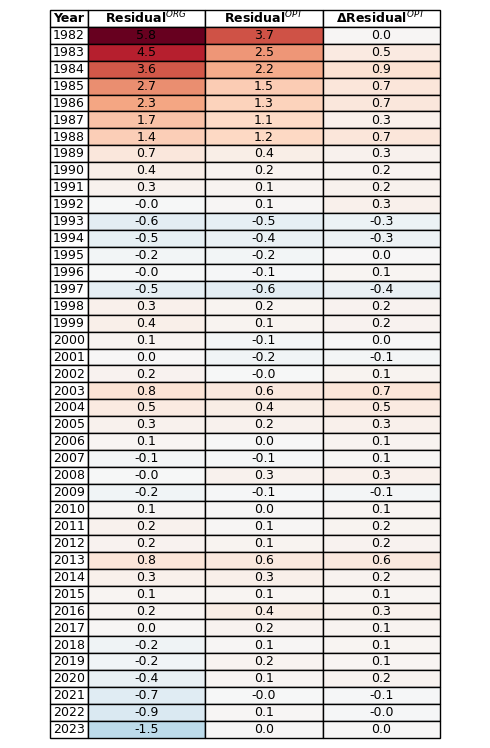

In [12]:
years = np.arange(1982, 2024)

df_bias = pd.DataFrame({
    "Year": years,
    r"Residual$^{ORG}$": testbed_mean_bias_org,
    r"Residual$^{OPT}$": testbed_mean_bias_opt,
    r"ΔResidual$^{OPT}$": testbed_mean_bias_delta})

bias_cols = [r"Residual$^{ORG}$", r"Residual$^{OPT}$", r"ΔResidual$^{OPT}$"]

for c in bias_cols:
    df_bias[c] = df_bias[c].apply(lambda x: x.item() if hasattr(x, "item") else x)
    df_bias[c] = pd.to_numeric(df_bias[c], errors="coerce")

cmap = plt.get_cmap("RdBu_r")
vmax = np.max(np.abs(df_bias[bias_cols].values))
vmin = -vmax
norm = mpl.colors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

display_values = df_bias.copy()
display_values["Year"] = display_values["Year"].astype(int)
for c in bias_cols:
    display_values[c] = display_values[c].map("{:.1f}".format)  # 2 decimals

cell_colors = []
for row in df_bias.itertuples(index=False):
    colors = []
    for i, c in enumerate(df_bias.columns):
        val = row[i]
        if c in bias_cols:
            colors.append(cmap(norm(val)))
        else:
            colors.append('white')
    cell_colors.append(colors)

col_widths = [0.08, 0.25, 0.25, 0.25]

fig_height = len(df_bias)*0.18
fig, ax = plt.subplots(figsize=(5, fig_height))
ax.axis('off')

table = ax.table(
    cellText=display_values.values,
    colLabels=display_values.columns,
    cellColours=cell_colors,
    cellLoc='center',
    loc='center',
    colWidths=col_widths)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1,1)

for (row, col), cell in table.get_celld().items():
    if row == 0:  # header row
        cell.get_text().set_fontweight('bold')

plt.tight_layout()
#fig.savefig("/home/jovyan/table_bias.jpg",dpi=300, bbox_inches="tight", transparent=True)

<>:9: SyntaxWarning: invalid escape sequence '\m'
<>:9: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_279/2410410380.py:9: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('Reconstruction bias ($\mu atm$)', fontsize=18)


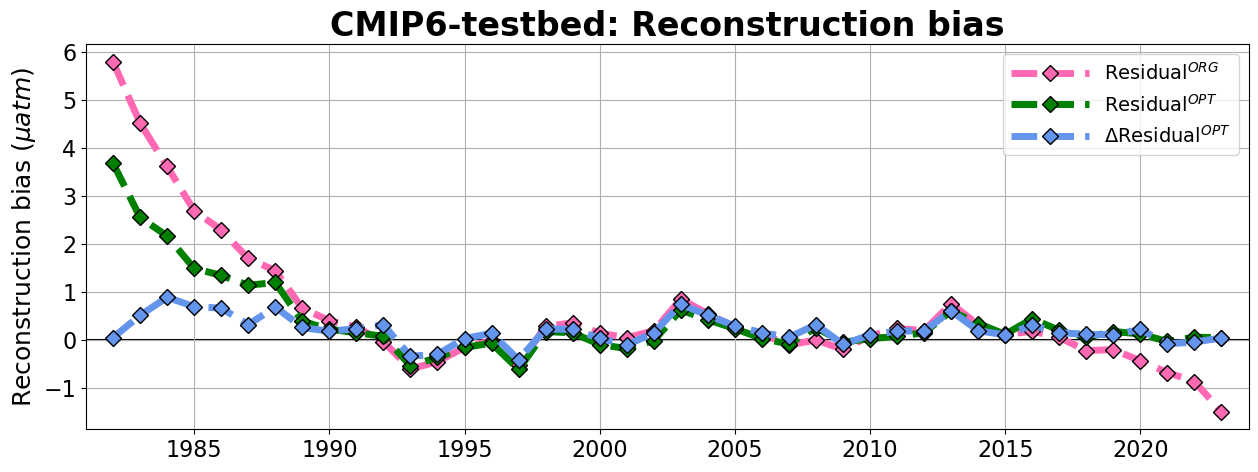

In [22]:
fig = plt.figure(figsize=(15,5))

plt.title('CMIP6-testbed: Reconstruction bias', fontsize=24, fontweight="bold")
plt.plot(model_mean_bias_org.year,testbed_mean_bias_org,linewidth=5.0,c='hotpink',label=r"Residual$^{ORG}$", linestyle='dashed', marker='D',markersize=8, markeredgecolor='black', markeredgewidth=1)
plt.plot(model_mean_bias_opt.year,testbed_mean_bias_opt,linewidth=5.0,c='green',label=r"Residual$^{OPT}$", linestyle='dashed', marker='D',markersize=8, markeredgecolor='black', markeredgewidth=1)
plt.plot(model_mean_bias_delta.year,testbed_mean_bias_delta,linewidth=5.0,c='cornflowerblue',label=r"ΔResidual$^{OPT}$", linestyle='dashed', marker='D',markersize=8, markeredgecolor='black', markeredgewidth=1)
plt.ylabel('Reconstruction bias ($\mu atm$)', fontsize=18)
plt.yticks(fontsize=16)
plt.xticks(fontsize=16)
plt.axhline(0,zorder=-10, color='black')
plt.xlim(1981,2024)
plt.grid(True)
plt.legend(loc='upper right',fontsize=14, handlelength=4);
#fig.savefig("/home/jovyan/timeseries_bias.jpg",dpi=300, bbox_inches="tight", transparent=True)

<>:75: SyntaxWarning: invalid escape sequence '\m'
<>:75: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_279/1622418086.py:75: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('Absolute bias ($\mu atm$)', fontsize=18)


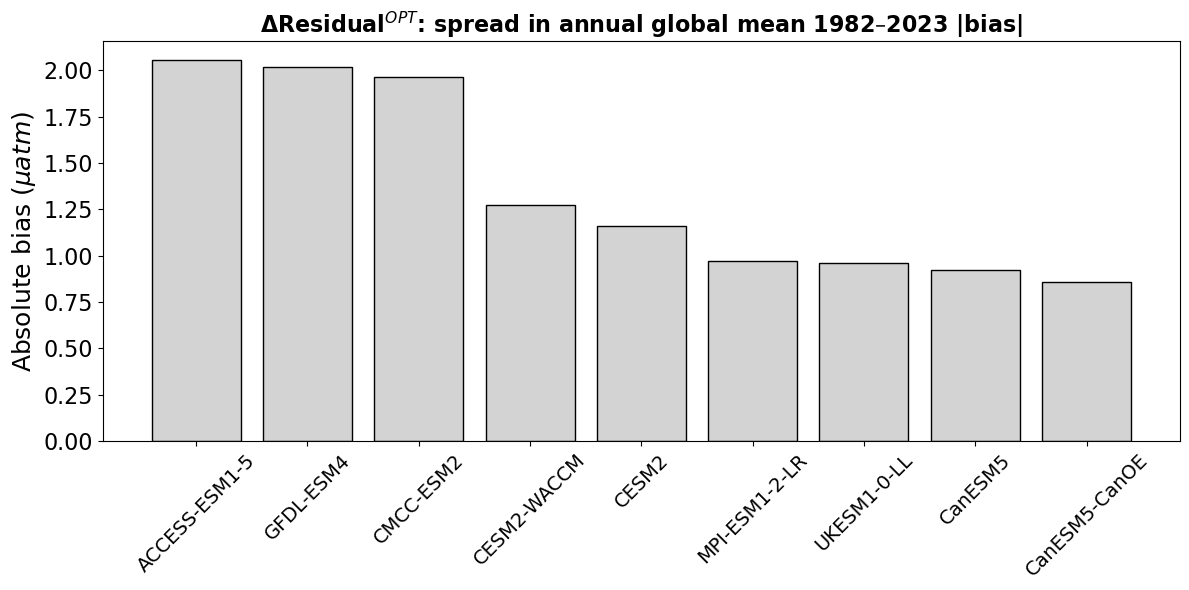

In [17]:
ref = datasets_ens_delta[0]
weights = np.cos(np.deg2rad(ref.ylat))
weights.name = "weights"

def bias_rmse_calc(ds, weights):
    
    bias = ds.diff('status')
    bias = bias.sel(time=slice("1982", "2023"))
    bias_weighted = bias.weighted(weights).mean(['ylat', 'xlon'])
    bias_final = bias_weighted.groupby("time.year").mean(['n_member', 'time'])
    return bias_final

fig = plt.figure(figsize=(12, 6))
esm_labels = []
bias_spreads = []

for ds in datasets_ens_delta:
    
    bias = bias_rmse_calc(ds, weights)
    bias_array = np.abs(bias.values.flatten())
    spread = np.max(bias_array) - np.min(bias_array)
    bias_spreads.append(spread)
    esm_labels.append(str(ds.ensemble.values))

sorted_indices = np.argsort(bias_spreads)[::-1]
sorted_spreads = np.array(bias_spreads)[sorted_indices]
sorted_labels  = np.array(esm_labels)[sorted_indices]

plt.bar(
    np.arange(len(sorted_spreads)),
    sorted_spreads,
    color='lightgray',
    edgecolor='black')

plt.title(
    r"ΔResidual$^{OPT}$: spread in annual global mean 1982–2023 |bias|",
    fontsize=16,
    fontweight="bold")
plt.ylabel('Absolute bias ($\mu atm$)', fontsize=18)
plt.xticks(
    np.arange(len(sorted_labels)),
    sorted_labels,
    rotation=45,
    fontsize=14)
plt.yticks(fontsize=16)
plt.tight_layout()

#fig.savefig("/home/jovyan/barplot_ESMs_spread_bias.jpg", dpi=300, bbox_inches="tight")

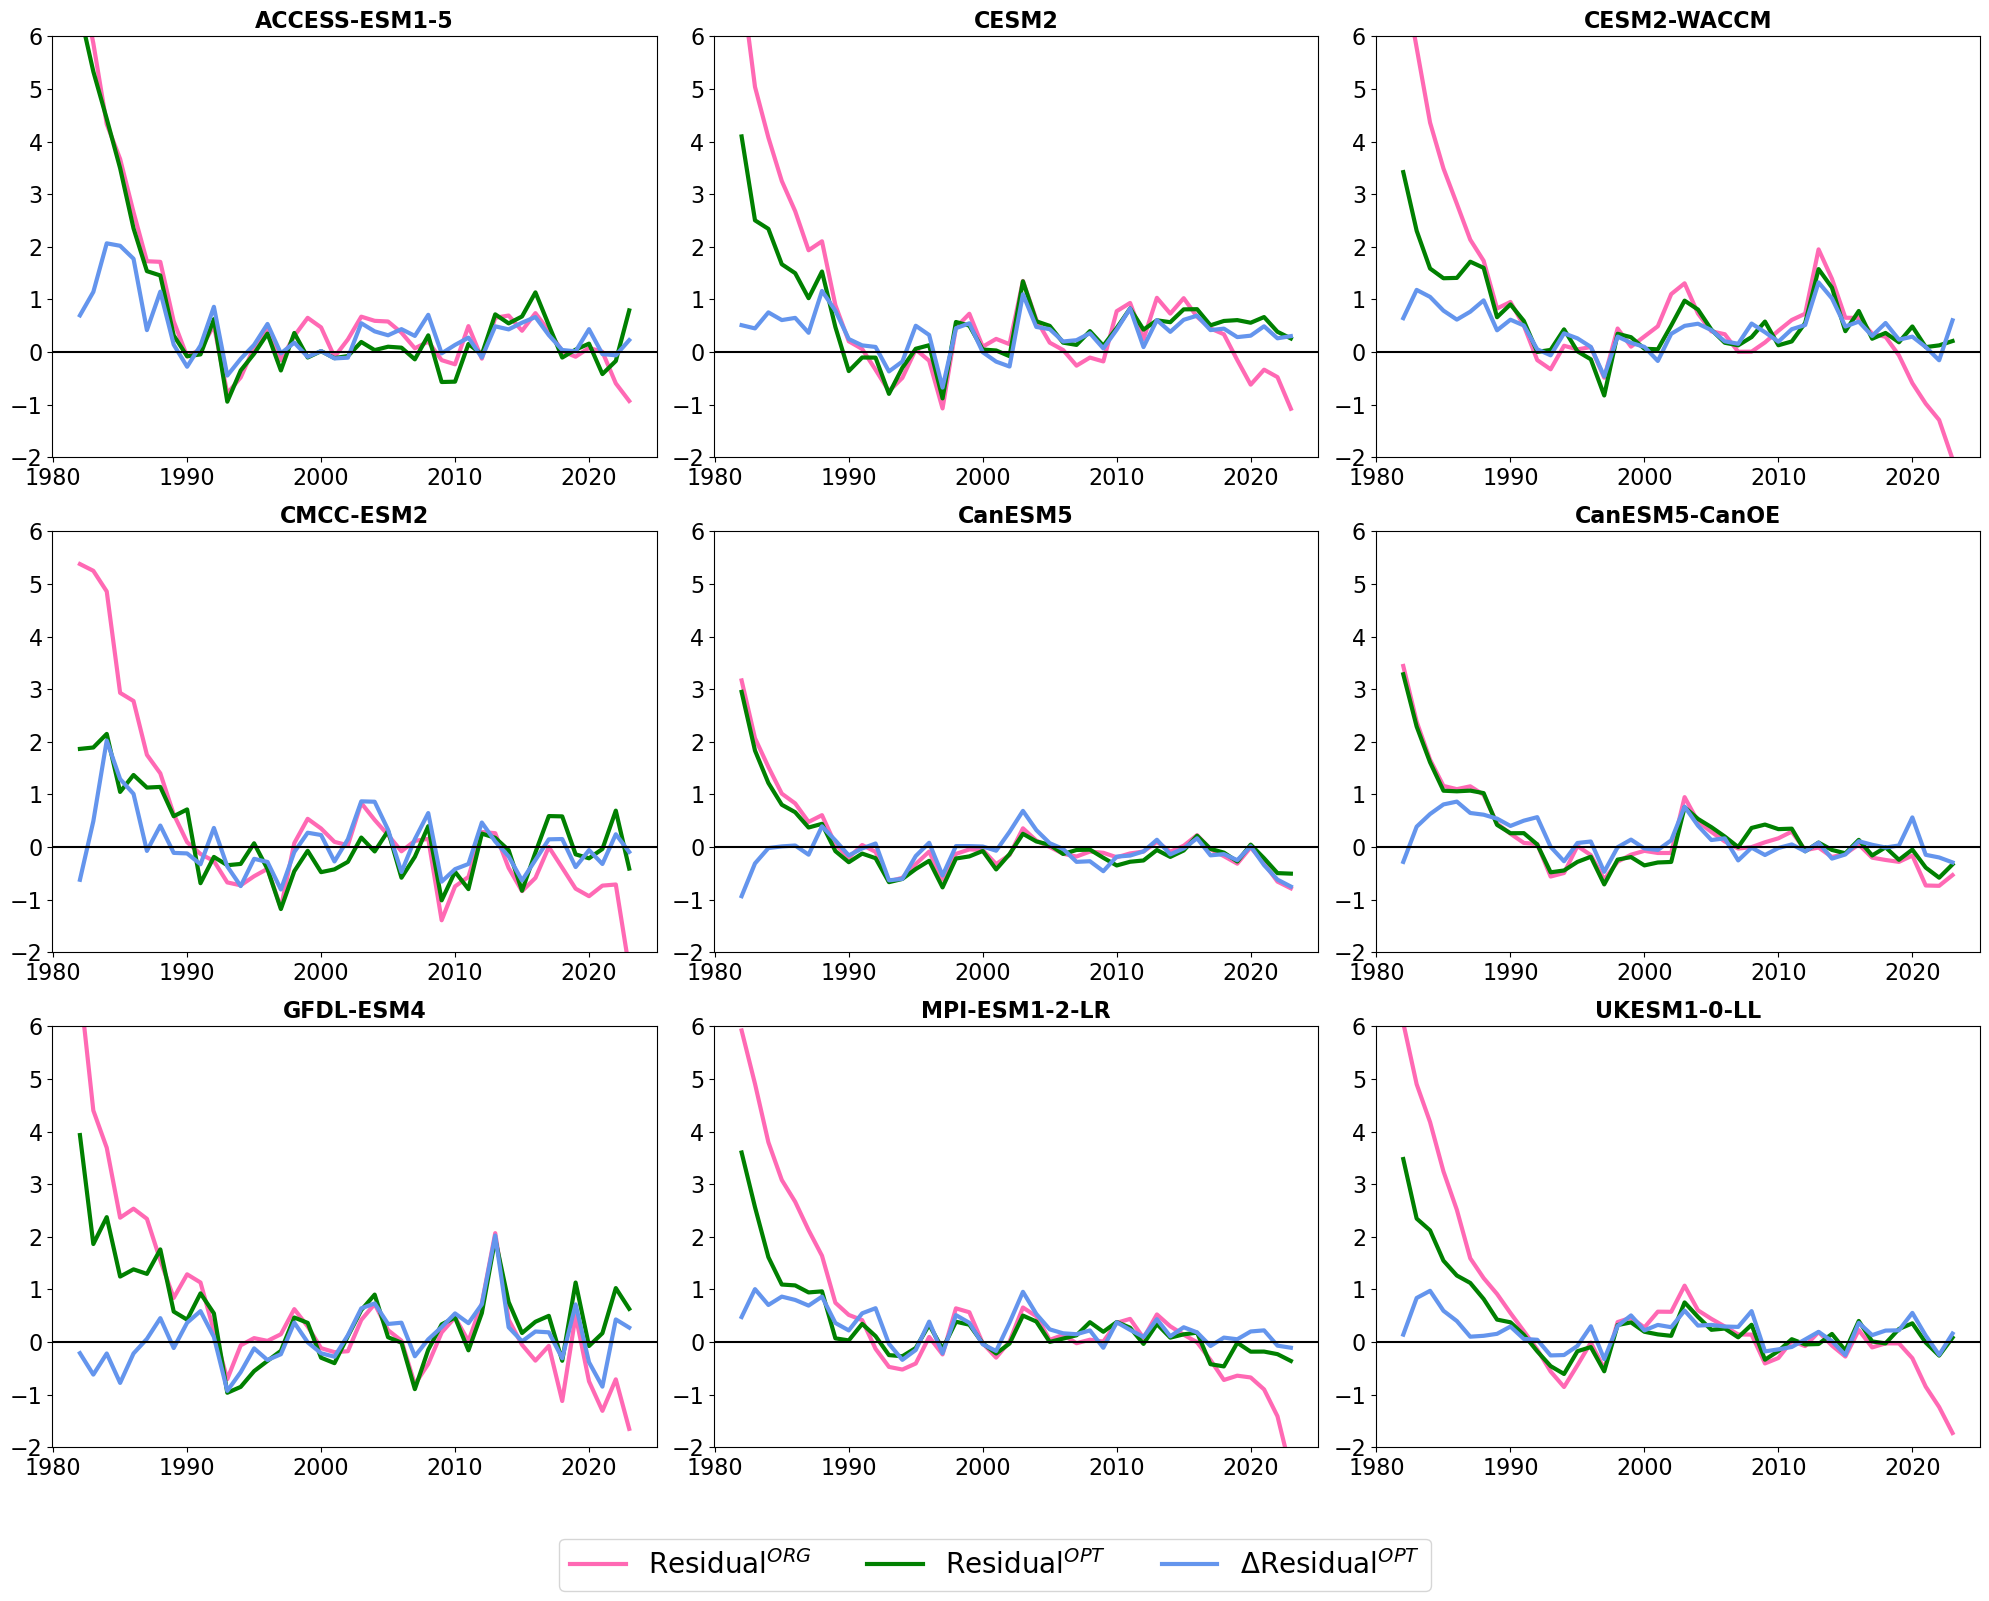

In [21]:
ref = datasets_ens_org[0]
weights = np.cos(np.deg2rad(ref.ylat))
weights.name = "weights"

def compute_weighted_bias(ds, weights):
    
    bias = ds.diff('status')
    bias = bias.sel(time=slice("1982-02-01", "2023-12-31"))
    bias = bias.weighted(weights).mean(['ylat', 'xlon'])
    bias = bias.groupby("time.year").mean(['time', 'n_member']) 
    return bias.squeeze()   

fig, axs = plt.subplots(3, 3, figsize=(20, 15))
axs = axs.flatten()

for i, ax in enumerate(axs):
    
    # --- ORG ---
    ds1 = datasets_ens_org[i]
    bias1 = compute_weighted_bias(ds1, weights)
    
    ax.plot(
        bias1.year,
        bias1.values,
        linewidth=3.0,
        color='hotpink',
        label=r"Residual$^{ORG}$")
    
    # --- OPT ---
    ds2 = datasets_ens_opt[i]
    bias2 = compute_weighted_bias(ds2, weights)
    
    ax.plot(
        bias2.year,
        bias2.values,
        linewidth=3.0,
        color='green',
        label=r"Residual$^{OPT}$")
    
    # --- DELTA ---
    ds3 = datasets_ens_delta[i]
    bias3 = compute_weighted_bias(ds3, weights)
    
    ax.plot(
        bias3.year,
        bias3.values,
        linewidth=3.0,
        color='cornflowerblue',
        label=r"ΔResidual$^{OPT}$")
    
    ax.set_title(str(ds1.ensemble.values), fontsize=16, fontweight="bold")
    ax.axhline(0, color='black')
    ax.set_ylim(-2, 6)
    ax.yaxis.set_tick_params(labelsize=16)
    ax.xaxis.set_tick_params(labelsize=16)

handles, labels = axs[0].get_legend_handles_labels()
unique = dict(zip(labels, handles))

fig.legend(
    unique.values(),
    unique.keys(),
    loc='upper center',
    bbox_to_anchor=(0.5, -0.02),
    ncol=3,
    fontsize=20)
plt.tight_layout()
#fig.savefig("/home/jovyan/timeseries_ESM_mean_bias.jpg", dpi=300, bbox_inches="tight")

## Maps

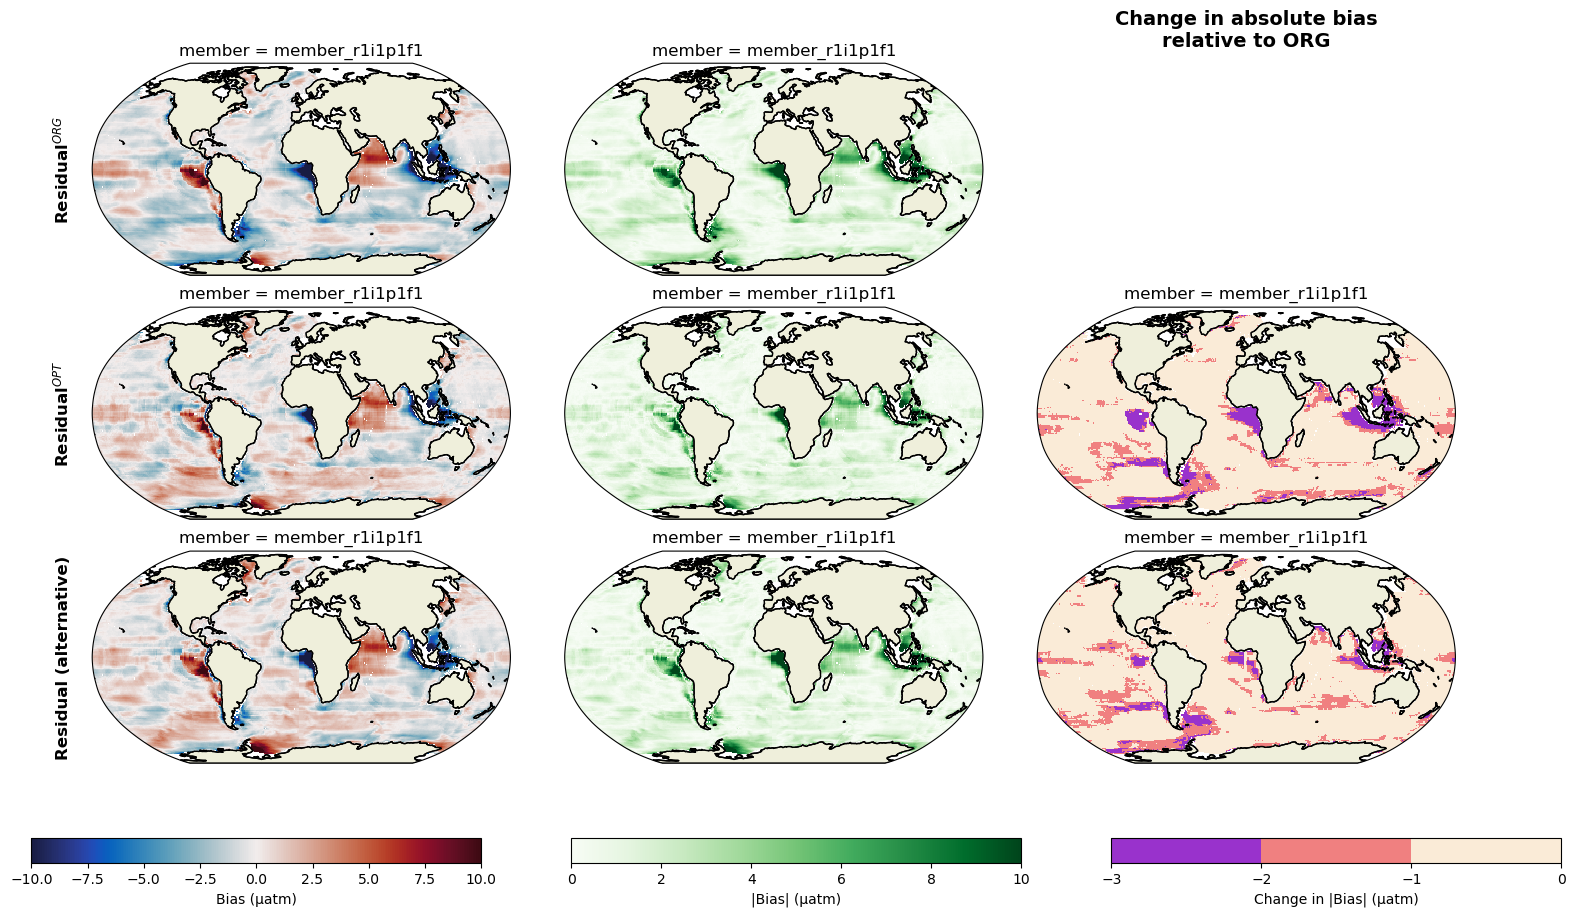

In [31]:
colors = ['darkorchid','lightcoral','antiquewhite']
cmap_diff = mcolors.ListedColormap(colors)
bounds = [-3, -2, -1, 0]
norm_diff = mcolors.BoundaryNorm(bounds, cmap_diff.N)

def compute_bias_map(datasets):
    out = []
    for ds in datasets:
        bias = (
            ds.diff('status')
              .sel(time=slice("2018-01-01", "2023-12-31"))
              .mean(['n_member', 'time', 'status'])
        )
        out.append(bias)
    return xr.concat(out, dim="ensemble").mean("ensemble")


bias_org = compute_bias_map(datasets_ens_org)
bias_opt = compute_bias_map(datasets_ens_opt)
bias_delta = compute_bias_map(datasets_ens_delta)

bias_delta = bias_delta.copy()
bias_delta[:, 180] = bias_delta[:, 181]
bias_delta[:, 179] = bias_delta[:, 181]
bias_delta[:, 178] = bias_delta[:, 181]
bias_delta[:, 177] = bias_delta[:, 176]

abs_org = np.abs(bias_org)
abs_opt = np.abs(bias_opt)
abs_delta = np.abs(bias_delta)

diff_opt = abs_opt - abs_org
diff_delta = abs_delta - abs_org

proj = ccrs.Robinson()

fig, axes = plt.subplots(
    3, 3,
    figsize=(18, 10),
    subplot_kw={'projection': proj})

plt.subplots_adjust(wspace=0.05, hspace=0.15, bottom=0.18)

col_titles = [
    "Mean bias",
    "Absolute mean bias",
    "Change in absolute bias\nrelative to ORG"]

for j in range(3):
    axes[0, j].set_title(col_titles[j],
                         fontsize=14,
                         fontweight='bold',
                         pad=12)

row_labels = [
    r"Residual$^{ORG}$",
    r"Residual$^{OPT}$",
    r"Residual (alternative)"]

bias_list = [bias_org, bias_opt, bias_delta]

for i in range(3):
    ax = axes[i, 0]

    ax.set_global()
    ax.coastlines()
    ax.add_feature(cfeature.LAND, edgecolor='black')

    img1 = bias_list[i].plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=cmocean.cm.balance,
        vmin=-10,
        vmax=10,
        add_colorbar=False)

    ax.text(
        -0.05, 0.5,
        row_labels[i],
        transform=ax.transAxes,
        rotation=90,
        va='center',
        ha='right',
        fontsize=12,
        fontweight='bold')


abs_list = [abs_org, abs_opt, abs_delta]

for i in range(3):
    ax = axes[i, 1]

    ax.set_global()
    ax.coastlines()
    ax.add_feature(cfeature.LAND, edgecolor='black')

    img2 = abs_list[i].plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap="Greens",
        vmin=0,
        vmax=10,
        add_colorbar=False)


axes[0, 2].axis('off')

ax = axes[1, 2]
ax.set_global()
ax.coastlines()
ax.add_feature(cfeature.LAND, edgecolor='black')

img3 = diff_opt.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap=cmap_diff,
    norm=norm_diff,
    add_colorbar=False)

ax = axes[2, 2]
ax.set_global()
ax.coastlines()
ax.add_feature(cfeature.LAND, edgecolor='black')

img3 = diff_delta.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap=cmap_diff,
    norm=norm_diff,
    add_colorbar=False)

cax1 = fig.add_axes([0.10, 0.08, 0.25, 0.025])
cbar1 = fig.colorbar(img1, cax=cax1, orientation='horizontal')
cbar1.set_label("Bias (µatm)")

cax2 = fig.add_axes([0.40, 0.08, 0.25, 0.025])
cbar2 = fig.colorbar(img2, cax=cax2, orientation='horizontal')
cbar2.set_label("|Bias| (µatm)")
cbar2.set_ticks([0, 2, 4, 6, 8, 10])

cax3 = fig.add_axes([0.70, 0.08, 0.25, 0.025])
cbar3 = fig.colorbar(img3, cax=cax3,
                     orientation='horizontal',
                     ticks=bounds)
cbar3.set_label("Change in |Bias| (µatm)")
#fig.savefig("/home/jovyan/map_2018-2023_bias.jpg",dpi=300, bbox_inches="tight")

In [20]:
model_mean_biases_org = []
for model in datasets_ens_org:
    model_mean_bias_org = model.diff('status').sel(time=slice("1982-02-01",'1987-12-31')).mean(['n_member','time', 'status'])
    model_mean_biases_org.append(model_mean_bias_org)
all_ens_org = xr.concat(model_mean_biases_org, dim='ensemble', join='override') 
bias_map_org  = all_ens_org.mean(dim='ensemble')

In [21]:
model_mean_biases_opt = []
for model in datasets_ens_opt:
    model_mean_bias_opt = model.diff('status').sel(time=slice("1982-02-01",'1987-12-31')).mean(['n_member','time', 'status'])
    model_mean_biases_opt.append(model_mean_bias_opt)
all_ens_opt = xr.concat(model_mean_biases_opt, dim='ensemble', join='override') 
bias_map_opt  = all_ens_opt.mean(dim='ensemble')

In [22]:
model_mean_biases_delta = []
for model in datasets_ens_delta:
    model_mean_bias_delta = model.diff('status').sel(time=slice("1982-02-01",'1987-12-31')).mean(['n_member','time', 'status'])
    model_mean_biases_delta.append(model_mean_bias_delta)
all_ens = xr.concat(model_mean_biases_delta, dim='ensemble', join='override') 
bias_map_delta = all_ens.mean(dim='ensemble')

bias_map_delta[40,181].values
bias_map_delta[:,180] = bias_map_delta[:,181]
bias_map_delta[:,179] = bias_map_delta[:,181]
bias_map_delta[:,178] = bias_map_delta[:,181]
bias_map_delta[:,177] = bias_map_delta[:,176]

<>:5: SyntaxWarning: invalid escape sequence '\m'
<>:5: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_4887/2768033763.py:5: SyntaxWarning: invalid escape sequence '\m'
  lab = f'Bias ($\mu atm$)'
/srv/conda/envs/notebook/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:379: UserWarning: The `map_projection` keyword argument is deprecated, use `projection` to instantiate a GeoAxes instead.
  warnings.warn("The `map_projection` keyword argument is "


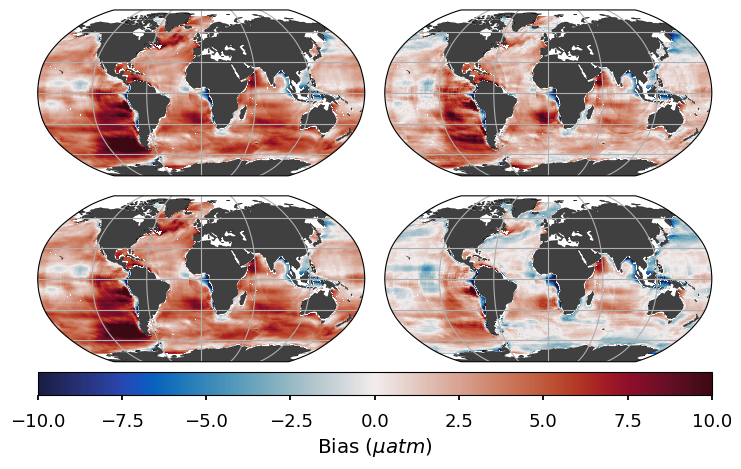

In [23]:
vrange = [-10, 10, 1]
fig_shape = (2,2)
cmap = cmocean.cm.balance
lab = f'Bias ($\mu atm$)'
     
with plt.style.context('seaborn-v0_8-talk'):
    fig = plt.figure(figsize=(20,5))

    dia = SpatialMap2(nrows_ncols=fig_shape, fig=fig, cbar_location='bottom', cbar_orientation='horizontal')

    sub = dia.add_plot(lat = bias_map_org['ylat'], 
                           lon = bias_map_org['xlon'], 
                           data = bias_map_org, 
                           vrange=vrange[0:2],
                           cmap=cmap, 
                           ax=0)

    sub = dia.add_plot(lat = bias_map_opt['ylat'], 
                           lon = bias_map_opt['xlon'], 
                           data = bias_map_opt, 
                           vrange=vrange[0:2],
                           cmap=cmap, 
                           ax=1)

    sub = dia.add_plot(lat = bias_map_org['ylat'], 
                           lon = bias_org['xlon'], 
                           data = bias_org, 
                           vrange=vrange[0:2],
                           cmap=cmap, 
                           ax=2)

    sub = dia.add_plot(lat = bias_map_delta['ylat'], 
                           lon = bias_map_delta['xlon'], 
                           data = bias_map_delta, 
                           vrange=vrange[0:2],
                           cmap=cmap, 
                           ax=3)

    col = dia.add_colorbar(sub)
    dia.set_cbar_xlabel(col, lab)

    gl = dia.grid[0].gridlines(draw_labels=False)
    gl = dia.grid[1].gridlines(draw_labels=False)
    gl = dia.grid[2].gridlines(draw_labels=False)
    gl = dia.grid[3].gridlines(draw_labels=False)
#fig.savefig("/home/jovyan/map_2018-2023_bias.jpg",dpi=300, bbox_inches="tight")

<>:40: SyntaxWarning: invalid escape sequence '\m'
<>:40: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_5620/3981200849.py:40: SyntaxWarning: invalid escape sequence '\m'
  cbar.set_label('Bias difference ($\mu$atm)', fontsize=16);


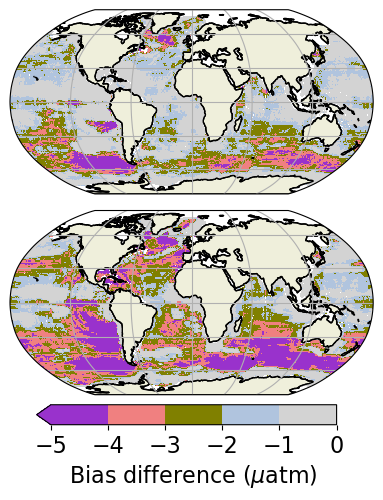

In [22]:
bias_map_change_abs_opt = bias_map_opt - bias_map_org
bias_map_change_abs_delta = bias_map_delta - bias_map_org

projection = ccrs.Robinson()
fig, axes = plt.subplots(2, 1, figsize=(20, 5), subplot_kw={'projection': projection})

plt.subplots_adjust(hspace=0.09)  
colors = ['darkorchid', 'lightcoral', 'olive', 'lightsteelblue', 'lightgray']
cmap = mcolors.ListedColormap(colors)
bounds = [-5, -4, -3, -2, -1, 0]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

datasets = [bias_map_change_abs_opt, bias_map_change_abs_delta]
titles = [r"Residual$^{OPT}$", r"ΔResidual$^{OPT}$"]
titles = ["", ""]

for i, (ax, data, title) in enumerate(zip(axes, datasets, titles)):
    ax.set_global()  
    ax.coastlines(resolution='110m')  
    ax.add_feature(cfeature.LAND, edgecolor='black')


    gl = ax.gridlines(draw_labels=False)
    gl.left_labels = False  
    gl.right_labels = False
    gl.top_labels = False
    gl.bottom_labels = False

    img = data.plot(ax=ax, transform=ccrs.PlateCarree(), cmap=cmap, norm=norm, add_colorbar=False)
    ax.set_title(title, fontsize=12, fontweight="bold")

cbar_ax = fig.add_axes([0.435, 0.05, 0.15, 0.04]) # x, vertical position, width, height
cbar = fig.colorbar(img, cax=cbar_ax, orientation="horizontal", ticks=bounds,extend='min')
cbar.set_label('Bias difference ($\mu$atm)', fontsize=16);
cbar.ax.tick_params(labelsize=16)
#plt.savefig("/home/jovyan/map_1982_1987_abs_bias.jpg",dpi=300, bbox_inches="tight", transparent=True);

## Boxplots

In [35]:
datasets_ens_org = []
for ens, mem_list in mems_dict.items():
    datasets_member = []
    for n_member, member in enumerate(mem_list):
        truth_path = f'gs://leap-persistent/abbysh/pco2_all_members_1982-2023/00_regridded_members/{ens}/{member}/{ens}.{member.split("_")[-1]}.Omon.zarr'
        recon_path = f"gs://leap-persistent/abbysh/pco2_all_members_1982-2023/post02_1982-2023_outputs/reconstructions/{ens}/{member}/recon_pCO2_{ens}_{member}_mon_1x1_198202_202312.zarr"
        kwargs = dict(chunks={'time':-1})
        
        truth = xr.open_dataset(truth_path, engine='zarr',**kwargs).spco2 
        unseen = xr.open_dataset(recon_path, engine='zarr',**kwargs).pCO2_recon_unseen 


        truth = truth.assign_coords(status='truth')
        unseen = unseen.assign_coords(status='unseen')
        

        truth = truth.assign_coords(time=unseen['time'].data)
        
        member_ds = xr.concat([truth, unseen], dim='status')
        

        member_ds = member_ds.assign_coords(n_member=n_member, member=member)
        
        datasets_member.append(member_ds)
    
    ds_ens = xr.concat(datasets_member, dim='n_member')
    ds_ens = ds_ens.assign_coords(ensemble=ens)
    
    
    datasets_ens_org.append(ds_ens)

In [34]:
datasets_ens_opt = []
for ens, mem_list in mems_dict.items():
    datasets_member = []
    for n_member, member in enumerate(mem_list):
        truth_path = f'gs://leap-persistent/abbysh/pco2_all_members_1982-2023/00_regridded_members/{ens}/{member}/{ens}.{member.split("_")[-1]}.Omon.zarr'
        recon_path = f"gs://leap-persistent/abbysh/pco2_all_members_1982-2023_optimized/post02_xgb/optimized/reconstructions/{ens}/{member}/recon_pCO2_{ens}_{member}_mon_1x1_198202_202312.zarr"
        kwargs = dict(chunks={'time':-1})
        
        truth = xr.open_dataset(truth_path, engine='zarr',**kwargs).spco2 
        unseen = xr.open_dataset(recon_path, engine='zarr',**kwargs).pCO2_recon_unseen 


        truth = truth.assign_coords(status='truth')
        unseen = unseen.assign_coords(status='unseen')
        

        truth = truth.assign_coords(time=unseen['time'].data)
        
        member_ds = xr.concat([truth, unseen], dim='status')
        

        member_ds = member_ds.assign_coords(n_member=n_member, member=member)
        
        datasets_member.append(member_ds)
    
    ds_ens = xr.concat(datasets_member, dim='n_member')
    ds_ens = ds_ens.assign_coords(ensemble=ens)
    
    
    datasets_ens_opt.append(ds_ens)

In [33]:
datasets_ens_delta = []
for ens, mem_list in mems_dict.items():
    datasets_member = []
    for n_member, member in enumerate(mem_list):
        truth_path = f'gs://leap-persistent/abbysh/pco2_all_members_1982-2023/00_regridded_members/{ens}/{member}/{ens}.{member.split("_")[-1]}.Omon.zarr'
        recon_path = f"gs://leap-persistent/hatlenheimdalthea/delta_pco2_all_members_1982-2023/bias/post02_xgb/reconstructions/{ens}/{member}/recon_pCO2_{ens}_{member}_mon_1x1_198202_202312.zarr"
        kwargs = dict(chunks={'time':-1})
        
        truth = xr.open_dataset(truth_path, engine='zarr',**kwargs).spco2.sel(time=slice("1982-02-01",'2023-12-31')) 
        unseen = xr.open_dataset(recon_path, engine='zarr',**kwargs).pCO2_recon_unseen.sel(time=slice("1982-02-01",'2023-12-31')) 


        truth = truth.assign_coords(status='truth')
        unseen = unseen.assign_coords(status='unseen')
        

        truth = truth.assign_coords(time=unseen['time'].data)
        
        member_ds = xr.concat([truth, unseen], dim='status')
        

        member_ds = member_ds.assign_coords(n_member=n_member, member=member)
        
        datasets_member.append(member_ds)
    
    ds_ens = xr.concat(datasets_member, dim='n_member')
    ds_ens = ds_ens.assign_coords(ensemble=ens)
    
    
    datasets_ens_delta.append(ds_ens)

In [29]:
concat_testbed_mean_org = xr.concat(datasets_ens_org, dim='ensemble', join='outer') 
concat_testbed_mean_opt = xr.concat(datasets_ens_opt, dim='ensemble', join='outer') 
concat_testbed_mean_delta = xr.concat(datasets_ens_delta, dim='ensemble', join='outer') 

/tmp/ipykernel_4887/337953311.py:1: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  concat_testbed_mean_org = xr.concat(datasets_ens_org, dim='ensemble', join='outer')
/tmp/ipykernel_4887/337953311.py:2: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  concat_testbed_mean_opt = xr.concat(datasets_ens_opt, dim='ensembl

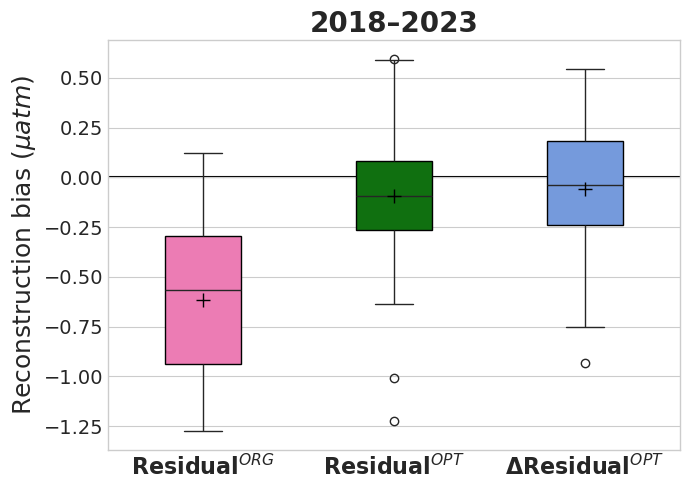

In [32]:
ref = concat_testbed_mean_org

weights = np.cos(np.deg2rad(ref.ylat))
weights.name = "weights"

def compute_bias_distribution(ds, weights, t0="2018-01-01", t1="2023-12-31"):
    
    bias = (
        ds
        .diff('status')
        .sel(time=slice(t0, t1))
        .weighted(weights).mean(['xlon', 'ylat'])   
        .mean('time'))
    
    return bias.values.flatten()


bias_all_org = compute_bias_distribution(concat_testbed_mean_org, weights)
bias_all_opt  = compute_bias_distribution(concat_testbed_mean_opt, weights)
bias_all_delta     = compute_bias_distribution(concat_testbed_mean_delta, weights)


colors = ['hotpink', 'green', 'cornflowerblue']
labels = [r"Residual$^{ORG}$", r"Residual$^{OPT}$", r"ΔResidual$^{OPT}$"]

with plt.style.context('seaborn-v0_8-whitegrid'):
    
    fig = plt.figure(figsize=(7, 5))
    
    sns.boxplot(
        data=[
            bias_all_org,
            bias_all_opt,
            bias_all_delta
        ],
        palette=colors,
        showmeans=True,
        width=0.4,
        meanprops={
            "marker": "+",
            "markeredgecolor": "black",
            "markersize": 10
        },
        boxprops=dict(edgecolor='black'))

    plt.title('2018–2023', fontsize=20, weight='bold')
    plt.ylabel(r'Reconstruction bias ($\mu atm$)', fontsize=18)

    plt.xticks(
        ticks=[0, 1, 2],
        labels=labels,
        fontsize=16,
        weight='bold')

    plt.yticks(fontsize=14)
    plt.axhline(0, color='black', zorder=-10)
    plt.tight_layout()
#plt.savefig("/home/jovyan/boxplots_bias.jpg",dpi=300,bbox_inches="tight")